<a href="https://colab.research.google.com/github/JakeOh/202605_BD57/blob/main/lab_python/da16_category.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Categorical Data(범주형 자료) 다루기

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 문자열 컬럼을 카테고리 타입으로 변환

In [2]:
df = pd.DataFrame(data={
    'user_id': np.arange(1, 11),
    'gender': ['M'] * 5 + ['F'] * 5,
    'score': np.random.randint(100, size=10),
})

In [3]:
df

,user_id,gender,score
0,1,M,67
1,2,M,67
2,3,M,76
3,4,M,1
4,5,M,2
5,6,F,19
6,7,F,44
7,8,F,64
8,9,F,58
9,10,F,66


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  10 non-null     int64 
 1   gender   10 non-null     object
 2   score    10 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 372.0+ bytes


In [6]:
df.gender = df.gender.astype('category')

In [7]:
df

,user_id,gender,score
0,1,M,67
1,2,M,67
2,3,M,76
3,4,M,1
4,5,M,2
5,6,F,19
6,7,F,44
7,8,F,64
8,9,F,58
9,10,F,66


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   user_id  10 non-null     int64   
 1   gender   10 non-null     category
 2   score    10 non-null     int64   
dtypes: category(1), int64(2)
memory usage: 426.0 bytes


In [9]:
# category 타입의 변수는 cat 속성(CategoricalAccesor)를 사용할 수 있음.
df.gender.cat.categories

Index(['F', 'M'], dtype='object')

In [10]:
df.gender.cat.ordered

False

# 연속형 변수에서 파생된 카테고리 변수 만들기

In [11]:
np.random.seed(42)

df = pd.DataFrame(data={
    'id': np.arange(1, 11),
    'age': np.random.randint(100, size=10)
})

In [12]:
df

,id,age
0,1,51
1,2,92
2,3,14
3,4,71
4,5,60
5,6,20
6,7,82
7,8,86
8,9,74
9,10,74


In [16]:
# age 변수를 이용해서 연령대(10대, 20대, 30대, ...) 파생변수를 추가
df['age_range'] = pd.cut(x=df.age, bins=np.arange(0, 110, 10), right=False)

In [17]:
df

,id,age,age_range
0,1,51,"[50, 60)"
1,2,92,"[90, 100)"
2,3,14,"[10, 20)"
3,4,71,"[70, 80)"
4,5,60,"[60, 70)"
5,6,20,"[20, 30)"
6,7,82,"[80, 90)"
7,8,86,"[80, 90)"
8,9,74,"[70, 80)"
9,10,74,"[70, 80)"


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   id         10 non-null     int64   
 1   age        10 non-null     int64   
 2   age_range  10 non-null     category
dtypes: category(1), int64(2)
memory usage: 762.0 bytes


In [19]:
df.age_range.cat.categories

IntervalIndex([  [0, 10),  [10, 20),  [20, 30),  [30, 40),  [40, 50),
                [50, 60),  [60, 70),  [70, 80),  [80, 90), [90, 100)],
              dtype='interval[int64, left]')

In [20]:
df.age_range.cat.ordered

True

In [28]:
# age 변수를 사용해서 문자열 카테고리 파생변수를 생성.
df['age_cat'] = pd.cut(x=df.age, bins=[0, 19, 35, 60, 100], right=False,
                       labels=['underage', 'young', 'middle', 'old'])

In [29]:
df

,id,age,age_range,age_cat
0,1,51,"[50, 60)",middle
1,2,92,"[90, 100)",old
2,3,14,"[10, 20)",underage
3,4,71,"[70, 80)",old
4,5,60,"[60, 70)",old
5,6,20,"[20, 30)",young
6,7,82,"[80, 90)",old
7,8,86,"[80, 90)",old
8,9,74,"[70, 80)",old
9,10,74,"[70, 80)",old


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   id         10 non-null     int64   
 1   age        10 non-null     int64   
 2   age_range  10 non-null     category
 3   age_cat    10 non-null     category
dtypes: category(2), int64(2)
memory usage: 976.0 bytes


In [31]:
df.age_cat.cat.categories

Index(['underage', 'young', 'middle', 'old'], dtype='object')

In [32]:
df.age_cat.cat.ordered

True

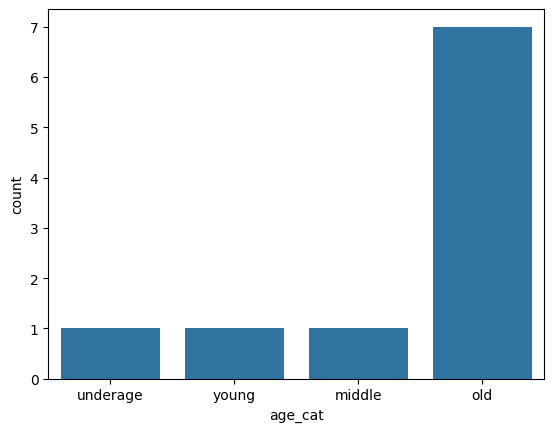

In [33]:
sns.countplot(data=df, x='age_cat')
plt.show()